In [2]:
import numpy as np
import h5py

# Load the posterior association catalog
catalog_path = "../output/dbscan_clusters_eps_2.75_ms_10.h5"

with h5py.File(catalog_path, 'r') as f:
    # Load summary arrays
    n_members = f['summary/n_members'][:]
    position_std = f['summary/position_std'][:]  # Shape: (N_assoc, 3)
    ambiguity_rate = f['summary/ambiguity_rate'][:]
    log10_m200_mass_std = f['summary/log10_m200_mass_std'][:]
    center_xyz = f['summary/center_xyz'][:]  # Shape: (N_assoc, 3)
    mean_m200_mass = f['summary/mean_m200_mass'][:]
    
    # Load metadata
    observer_coords = f['metadata'].attrs['observer_coords']
    
    # Compute sigma_R as the magnitude of position std (association size)
    sigma_R = np.sqrt(np.sum(position_std**2, axis=1))
    
    # Load persistence if available
    if 'summary/persistence_score' in f:
        persistence = f['summary/persistence_score'][:]
    else:
        persistence = np.ones(len(n_members))  # Default to 1 if not present
        print("Note: persistence not found in catalog, defaulting to 1.0")

# Compute positions relative to observer
rel_pos = center_xyz - observer_coords
distance = np.linalg.norm(rel_pos, axis=1)

# Compute RA/Dec (in degrees)
ra = np.degrees(np.arctan2(rel_pos[:, 1], rel_pos[:, 0]))
dec = np.degrees(np.arcsin(rel_pos[:, 2] / distance))

# Store all data in a dict for easy access
data = {
    'n_members': n_members,
    'sigma_R': sigma_R,
    'persistence': persistence,
    'ambiguity_rate': ambiguity_rate,
    'sigma_log_M': log10_m200_mass_std,
    'center_xyz': center_xyz,
    'mean_m200_mass': mean_m200_mass,
    'log10_mass': np.log10(mean_m200_mass),
    'distance': distance,
    'ra': ra,
    'dec': dec,
}

print(f"Loaded {len(n_members)} associations")

Note: persistence not found in catalog, defaulting to 1.0
Loaded 1210 associations


In [7]:
# Define selection samples
# Each entry: 'name': {'persistence': (min, max), 'ambiguity_rate': (min, max), 
#                      'sigma_R': (min, max), 'sigma_log_M': (min, max), 'n_members': (min, max)}
# Use None for no constraint on that parameter

selections = {
    'Raw': {},  # No cuts
    'Fiducial': {
        'ambiguity_rate': (None, 0.05),
        'n_members': (20, None),
    },
    'Strict': {
        'ambiguity_rate': (None, 0.05),
        'n_members': (20, None),
        'sigma_R': (None, 2.5),
        'sigma_log_M': (None, 0.25),
    },
}

def apply_selection(data, cuts):
    """Apply selection cuts and return boolean mask."""
    mask = np.ones(len(data['n_members']), dtype=bool)
    
    for key, (lo, hi) in cuts.items():
        if key not in data:
            print(f"Warning: {key} not in data, skipping")
            continue
        if lo is not None:
            mask &= data[key] >= lo
        if hi is not None:
            mask &= data[key] <= hi
    
    return mask

# Compute masks for all selections
masks = {name: apply_selection(data, cuts) for name, cuts in selections.items()}

# Report counts
print(f"{'Selection':<15} {'N_assoc':>10} {'Fraction':>10}")
print("-" * 37)
n_total = len(data['n_members'])
for name, mask in masks.items():
    n = np.sum(mask)
    print(f"{name:<15} {n:>10} {n/n_total:>10.1%}")

Selection          N_assoc   Fraction
-------------------------------------
Raw                   1210     100.0%
Fiducial               434      35.9%
Strict                 191      15.8%


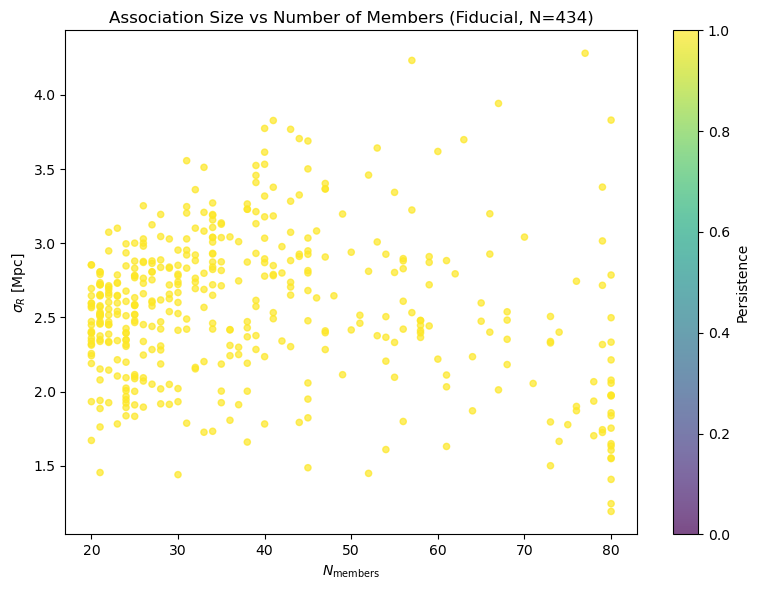

In [8]:
import matplotlib.pyplot as plt

# Choose which selection to plot
selection_name = 'Fiducial'
mask = masks[selection_name]

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(data['n_members'][mask], data['sigma_R'][mask], 
                     c=data['persistence'][mask], cmap='viridis', 
                     alpha=0.7, s=20, vmin=0, vmax=1)
plt.colorbar(scatter, ax=ax, label='Persistence')

ax.set_xlabel('$N_{\\rm members}$')
ax.set_ylabel('$\\sigma_R$ [Mpc]')
ax.set_title(f'Association Size vs Number of Members ({selection_name}, N={np.sum(mask)})')

plt.tight_layout()
plt.show()

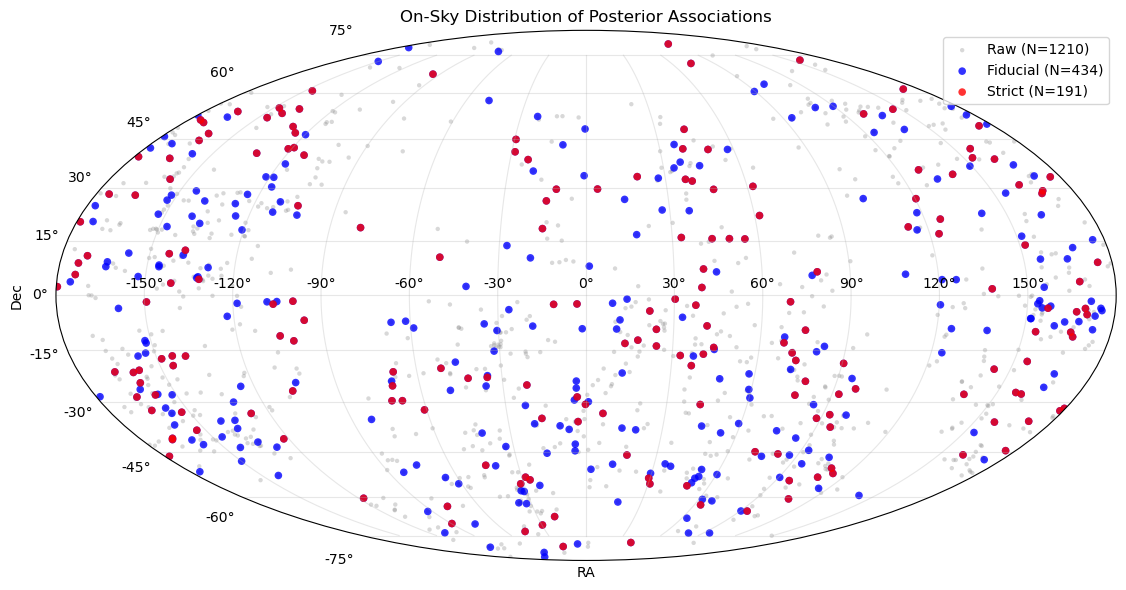

In [9]:
# On-sky distribution (Mollweide projection)
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': 'mollweide'})

colors = {'Raw': 'gray', 'Fiducial': 'blue', 'Strict': 'red'}

for name in ['Raw', 'Fiducial', 'Strict']:
    mask = masks[name]
    ra_rad = np.radians(data['ra'][mask])
    dec_rad = np.radians(data['dec'][mask])
    
    # Mollweide expects longitude in [-pi, pi]
    ra_rad = np.where(ra_rad > np.pi, ra_rad - 2*np.pi, ra_rad)
    
    alpha = 0.3 if name == 'Raw' else 0.8
    size = 10 if name == 'Raw' else 30
    ax.scatter(ra_rad, dec_rad, s=size, alpha=alpha, label=f'{name} (N={np.sum(mask)})', 
               c=colors[name], edgecolors='none')

ax.set_xlabel('RA')
ax.set_ylabel('Dec')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_title('On-Sky Distribution of Posterior Associations')
plt.tight_layout()
plt.show()

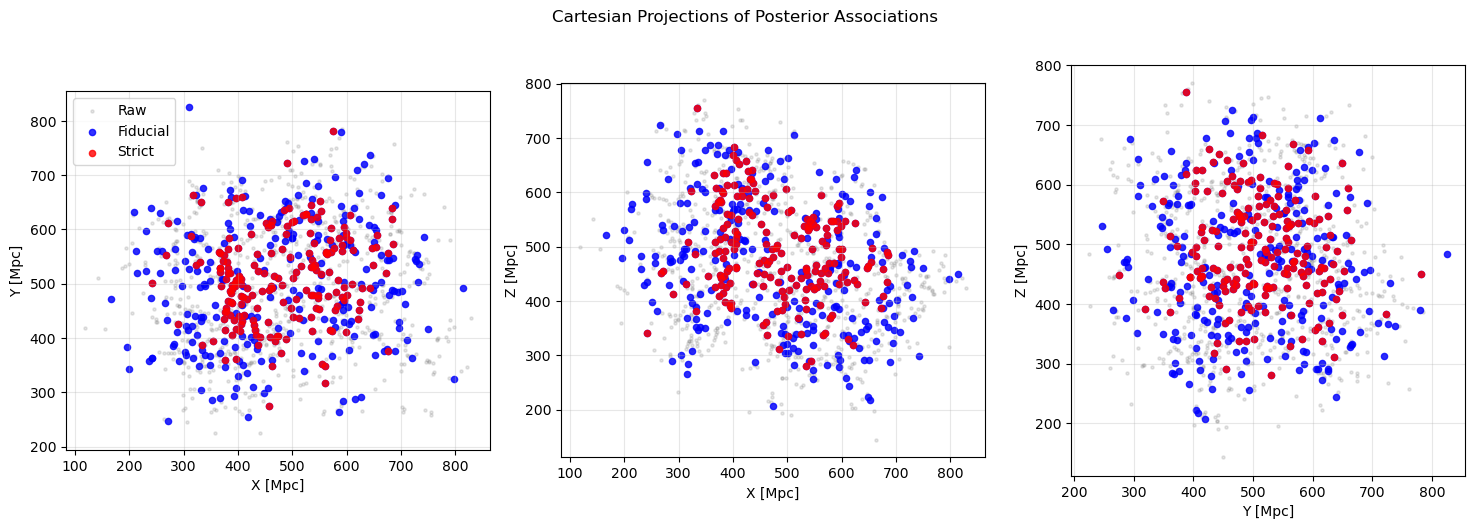

In [10]:
# Cartesian projections (X-Y, X-Z, Y-Z)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

projections = [('X', 'Y', 0, 1), ('X', 'Z', 0, 2), ('Y', 'Z', 1, 2)]
colors = {'Raw': 'gray', 'Fiducial': 'blue', 'Strict': 'red'}

for ax, (xlabel, ylabel, i, j) in zip(axes, projections):
    for name in ['Raw', 'Fiducial', 'Strict']:
        mask = masks[name]
        pos = data['center_xyz'][mask]
        
        alpha = 0.2 if name == 'Raw' else 0.8
        size = 5 if name == 'Raw' else 20
        ax.scatter(pos[:, i], pos[:, j], s=size, alpha=alpha, 
                   label=f'{name}' if i == 0 and j == 1 else '', c=colors[name])
    
    ax.set_xlabel(f'{xlabel} [Mpc]')
    ax.set_ylabel(f'{ylabel} [Mpc]')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

axes[0].legend()
fig.suptitle('Cartesian Projections of Posterior Associations', y=1.02)
plt.tight_layout()
plt.show()

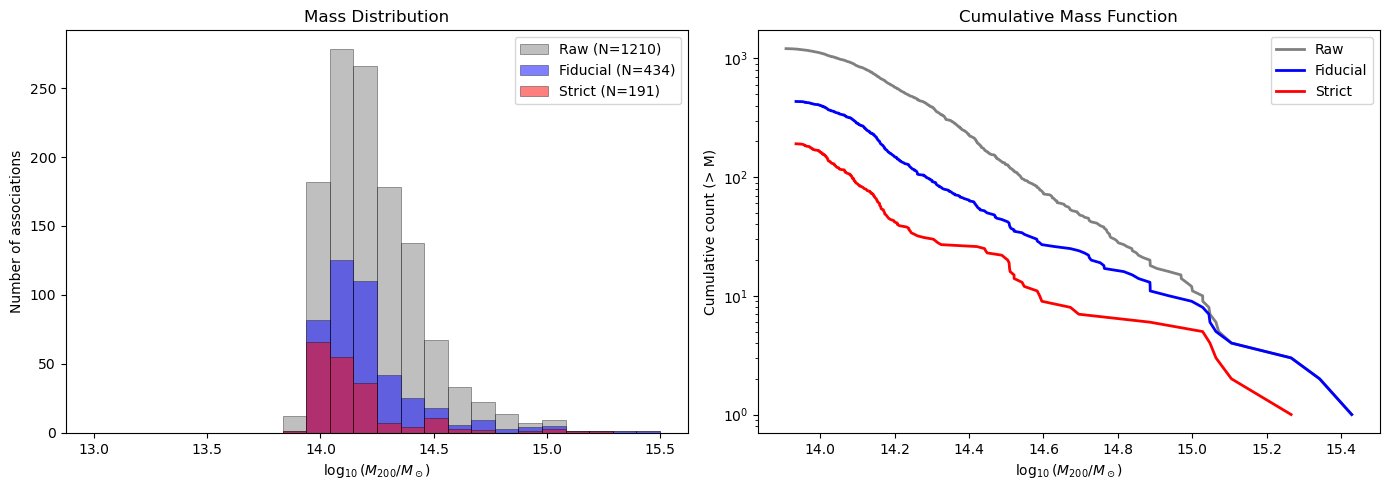

In [11]:
# Mass distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Raw': 'gray', 'Fiducial': 'blue', 'Strict': 'red'}

# Histogram
ax = axes[0]
bins = np.linspace(13, 15.5, 25)
for name in ['Raw', 'Fiducial', 'Strict']:
    mask = masks[name]
    ax.hist(data['log10_mass'][mask], bins=bins, alpha=0.5, label=f'{name} (N={np.sum(mask)})', 
            color=colors[name], edgecolor='black', linewidth=0.5)

ax.set_xlabel(r'$\log_{10}(M_{200} / M_\odot)$')
ax.set_ylabel('Number of associations')
ax.legend()
ax.set_title('Mass Distribution')

# Cumulative
ax = axes[1]
for name in ['Raw', 'Fiducial', 'Strict']:
    mask = masks[name]
    sorted_mass = np.sort(data['log10_mass'][mask])[::-1]
    ax.plot(sorted_mass, np.arange(1, len(sorted_mass)+1), label=f'{name}', 
            color=colors[name], linewidth=2)

ax.set_xlabel(r'$\log_{10}(M_{200} / M_\odot)$')
ax.set_ylabel('Cumulative count (> M)')
ax.legend()
ax.set_title('Cumulative Mass Function')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

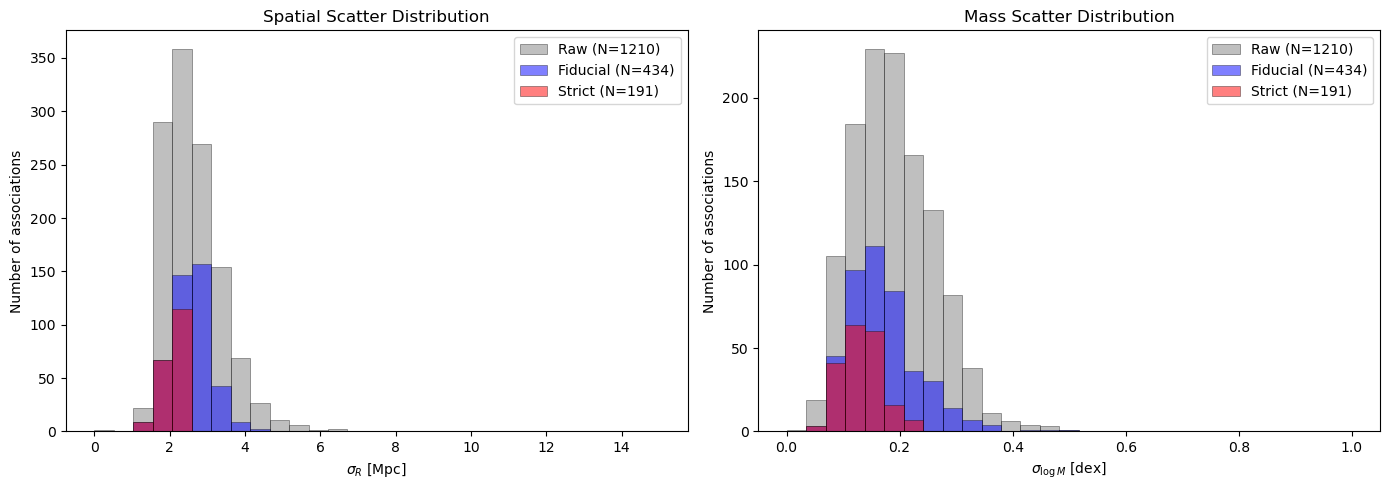

In [12]:
# sigma_R distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Raw': 'gray', 'Fiducial': 'blue', 'Strict': 'red'}

# sigma_R histogram
ax = axes[0]
bins = np.linspace(0, 15, 30)
for name in ['Raw', 'Fiducial', 'Strict']:
    mask = masks[name]
    ax.hist(data['sigma_R'][mask], bins=bins, alpha=0.5, label=f'{name} (N={np.sum(mask)})', 
            color=colors[name], edgecolor='black', linewidth=0.5)

ax.set_xlabel(r'$\sigma_R$ [Mpc]')
ax.set_ylabel('Number of associations')
ax.legend()
ax.set_title('Spatial Scatter Distribution')

# sigma_log_M histogram
ax = axes[1]
bins = np.linspace(0, 1, 30)
for name in ['Raw', 'Fiducial', 'Strict']:
    mask = masks[name]
    ax.hist(data['sigma_log_M'][mask], bins=bins, alpha=0.5, label=f'{name} (N={np.sum(mask)})', 
            color=colors[name], edgecolor='black', linewidth=0.5)

ax.set_xlabel(r'$\sigma_{\log M}$ [dex]')
ax.set_ylabel('Number of associations')
ax.legend()
ax.set_title('Mass Scatter Distribution')

plt.tight_layout()
plt.show()

/tmp/ipykernel_12096/2869563558.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


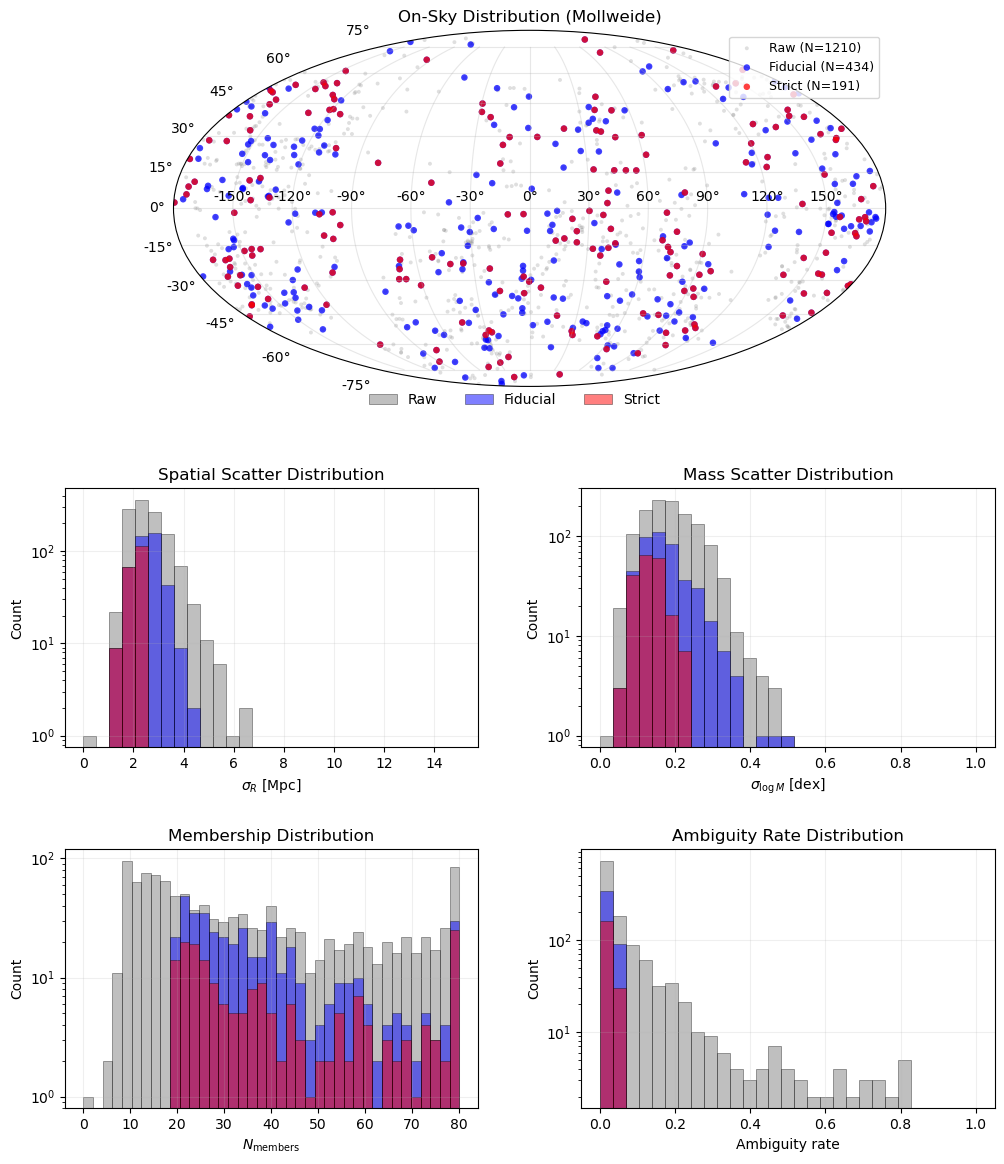

In [14]:
# Combined summary plot: Mollweide on top + 2x2 histograms underneath (incl. ambiguity_rate)
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 14))

colors = {'Raw': 'gray', 'Fiducial': 'blue', 'Strict': 'red'}
names = ['Raw', 'Fiducial', 'Strict']

# Layout: 3 rows x 2 cols
# - Top row spans both columns (Mollweide)
# - Bottom 2 rows are a 2x2 grid of hist panels
gs = fig.add_gridspec(nrows=3, ncols=2, height_ratios=[2.2, 1.6, 1.6], hspace=0.35, wspace=0.25)

# --- Top: Mollweide on-sky distribution ---
ax_sky = fig.add_subplot(gs[0, :], projection='mollweide')
for name in names:
    mask = masks[name]
    ra_rad = np.radians(data['ra'][mask])
    dec_rad = np.radians(data['dec'][mask])

    # wrap RA into [-pi, pi] for mollweide
    ra_rad = np.where(ra_rad > np.pi, ra_rad - 2*np.pi, ra_rad)

    alpha = 0.25 if name == 'Raw' else 0.75
    size  = 8 if name == 'Raw' else 22
    ax_sky.scatter(
        ra_rad, dec_rad,
        s=size, alpha=alpha,
        label=f'{name} (N={np.sum(mask)})',
        c=colors[name], edgecolors='none'
    )

ax_sky.legend(loc='upper right', fontsize=9)
ax_sky.grid(True, alpha=0.3)
ax_sky.set_title('On-Sky Distribution (Mollweide)')

# --- Helper for hist panels ---
def hist_panel(ax, field, bins, xlabel, title, logy=True):
    for name in names:
        mask = masks[name]
        ax.hist(
            data[field][mask],
            bins=bins,
            alpha=0.5,
            label=name,
            color=colors[name],
            edgecolor='black',
            linewidth=0.5
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    if logy:
        ax.set_yscale('log')
    ax.grid(True, alpha=0.2)
    ax.set_title(title)

# --- Bottom 2x2: Histograms ---
ax_sigR   = fig.add_subplot(gs[1, 0])
ax_sigM   = fig.add_subplot(gs[1, 1])
ax_nmem   = fig.add_subplot(gs[2, 0])
ax_ambig  = fig.add_subplot(gs[2, 1])

hist_panel(
    ax_sigR, 'sigma_R',
    bins=np.linspace(0, 15, 30),
    xlabel=r'$\sigma_R$ [Mpc]',
    title='Spatial Scatter Distribution'
)

hist_panel(
    ax_sigM, 'sigma_log_M',
    bins=np.linspace(0, 1, 30),
    xlabel=r'$\sigma_{\log M}$ [dex]',
    title='Mass Scatter Distribution'
)

hist_panel(
    ax_nmem, 'n_members',
    bins=np.linspace(0, 80, 40),
    xlabel=r'$N_{\rm members}$',
    title='Membership Distribution'
)

# ambiguity_rate histogram (adjust bins if you know the expected range)
# If ambiguity_rate is in [0,1], this is appropriate; otherwise tweak.
hist_panel(
    ax_ambig, 'ambiguity_rate',
    bins=np.linspace(0, 1, 30),
    xlabel='Ambiguity rate',
    title='Ambiguity Rate Distribution',
    logy=True
)

# One legend for all hist panels (keep sky legend separate)
handles, labels = ax_sigR.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncols=3, frameon=False, bbox_to_anchor=(0.5, 0.63))

plt.tight_layout()
plt.savefig("plots/cluster_selection_dists.pdf")
plt.show()
